# Tutorial
Ganti runtime type dengan klik panah bawah di sebelah tulisan connect dan klik pada change runtime type
Pilih T4 GPU lalu klik save
Lalu tinggal jalankan kode di bawah ini hingga mencapai teks "Testing"

Training model memakan waktu sekitar 2 jam, pastikan agar laptop/komputer yang melakukan training tidak masuk idle/tidak digunakan, tetap awasi dengan gerakan kursor mouse agar tidak dianggap diam oleh google colab sehingga tidak terputus koneksi ketika training model

Ketika training selesai, cek dengan klik pada ikon folder/files di sebelah kiri dibawah ikon kunci, lalu cari runs/detect/{} di dalamnya ada folder weights, di sinilah model tersimpan, bisa didownload untuk last.pt atau best.pt

# Training

In [ ]:
# 1. Install Library dan Download Dataset
!pip install roboflow tensorflow

from roboflow import Roboflow
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import os
import json

# Masukkan API Key Roboflow
rf = Roboflow(api_key="oSqbdWgbnJkiVfOWl18o")
project = rf.workspace("valll-rtclj").project("sapi-lokal")
version = project.version(1)
dataset = version.download("folder")


# 2. Menyiapkan Path Dataset
TRAIN_DIR = f"{dataset.location}/train"
VALID_DIR = f"{dataset.location}/valid"


# 3. Preprocessing Data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("🔍 Membaca data dari struktur folder...")

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes

if NUM_CLASSES == 0:
    print("❌ ERROR: Tidak ada kelas yang ditemukan!")
else:
    print(
        f"✅ Ditemukan {NUM_CLASSES} kelas: "
        f"{list(train_generator.class_indices.keys())}"
    )


# 4. Memuat Model MobileNetV3Large
base_model = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


# 5. Menambahkan Layer Klasifikasi
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)

predictions = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)


# 6. Kompilasi Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# 7. Menyiapkan Checkpoint dan Training
BEST_MODEL_PATH = '/content/lokalbest.keras'
LAST_MODEL_PATH = '/content/lokallast.keras'
CHECKPOINT_DIR = '/content/checkpoints_v3'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Menyimpan model dengan validation accuracy terbaik
best_checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Menyimpan model setiap epoch
epoch_checkpoint = ModelCheckpoint(
    filepath=os.path.join(
        CHECKPOINT_DIR,
        'epoch_{epoch:02d}_valacc_{val_accuracy:.4f}.keras'
    ),
    save_best_only=False,
    save_weights_only=False,
    verbose=0
)

csv_logger = CSVLogger(
    '/content/training_log_v3.csv',
    append=False
)

print("\n🚀 Memulai training MobileNetV3Large selama 50 epoch...")

history = model.fit(
    train_generator,
    epochs=50,
    validation_data=valid_generator,
    callbacks=[
        best_checkpoint,
        epoch_checkpoint,
        csv_logger
    ]
)


# 8. Menyimpan Model dan Nama Kelas
model.save(LAST_MODEL_PATH)

class_indices = {
    v: k
    for k, v in train_generator.class_indices.items()
}

with open('/content/class_names.json', 'w') as f:
    json.dump(class_indices, f, indent=4)

print("\n✅ Training selesai.")
print(f"🏆 Best model : {BEST_MODEL_PATH}")
print(f"📌 Last model : {LAST_MODEL_PATH}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to sapi-lokal-1 in folder:: 100%|██████████| 301/301 [00:00<00:00, 10491.16it/s]

🔍 Membaca data dari struktur folder...
Found 261 images belonging to 6 classes.
Found 20 images belonging to 6 classes.


✅ Ditemukan 6 kelas: ['aceh', 'bali', 'limusin', 'madura', 'pasundan', 'po']
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,120,134 (11.90 MB)

 Trainable params: 123,782 (483.52 KB)

 Non-trainable params: 2,996,352 (11.43 MB)


🚀 Memulai training MobileNetV3Large selama 50 epoch...
Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3251 - loss: 1.8523
Epoch 1: val_accuracy improved from None to 0.60000, saving model to /content/pmkbest.keras

Epoch 1: finished saving model to /content/pmkbest.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.4636 - loss: 1.5690 - val_accuracy: 0.6000 - val_loss: 1.2458
Epoch 2/50
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7296 - loss: 0.7601
Epoch 2: val_accuracy improved from 0.60000 to 0.75000, saving model to /content/pmkbest.keras

Epoch 2: finished saving model to /content/pmkbest.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 193ms/step - accuracy: 0.7586 - loss: 0.6737 - val_accuracy: 0.7500 - val_loss: 0.7896
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8694 - loss: 0.4616
Epoch 3: val_accuracy improved from 0.75000 to 0.80000, saving model to /content/pmkbest.keras

Epoch 3: finished saving model to /content/pmkbest.keras
9/9 ━━━━━━━━

# Testing


📦 Memulai prediksi pada gambar: /content/3.jpg

Probabilitas setiap kelas:
aceh: 0.0000
bali: 0.9996
limusin: 0.0003
madura: 0.0000
pasundan: 0.0000
po: 0.0001

✅ Hasil Visual Klasifikasi:


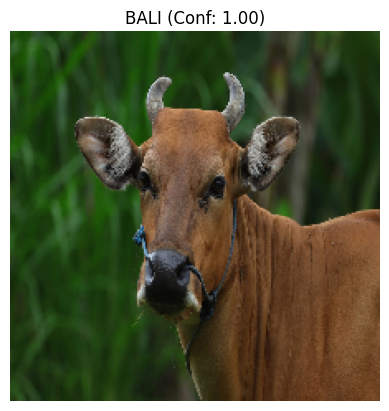


💡 Kesimpulan Prediksi:
    - Terdeteksi sebagai: BALI
    - Tingkat keyakinan: 99.96%

📄 Output JSON:
{
  "predictions": [
    {
      "class": "bali",
      "class_id": 1,
      "confidence": 0.9995890855789185
    }
  ]
}


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import json
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

def prediksi_mobilenet(image_path, model_path, class_json_path):
    # 1. Memuat model dan file JSON berisi nama kelas
    try:
        model = load_model(model_path)
        with open(class_json_path, 'r') as f:
            # Karena JSON key selalu string (misal: "0", "1"), kita biarkan aslinya
            class_names = json.load(f)
    except Exception as e:
        print("❌ ERROR: Gagal memuat model atau file JSON kelas.")
        print(e)
        return {"predictions": []}

    print(f"\n📦 Memulai prediksi pada gambar: {image_path}")

    # 2. Memuat dan memproses gambar uji (harus disamakan dengan saat training: 224x224 dan rescale 1/255)
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)


    # 3. Melakukan inferensi / tebakan model
    predictions = model.predict(img_array, verbose=0)
    print("\nProbabilitas setiap kelas:")
    for idx, prob in enumerate(predictions[0]):
        print(f"{class_names[str(idx)]}: {prob:.4f}")


    # 4. Mencari kelas dengan probabilitas / confidence tertinggi
    predicted_class_idx = np.argmax(predictions[0])
    confidence = float(predictions[0][predicted_class_idx])

    # Mengambil nama label berdasarkan index (mengubah index ke string untuk mencocokkan key JSON)
    predicted_label = class_names[str(predicted_class_idx)]

    # 5. Menampilkan gambar dan hasil prediksi
    print("\n✅ Hasil Visual Klasifikasi:")
    plt.imshow(img)
    plt.title(f"{predicted_label.upper()} (Conf: {confidence:.2f})")
    plt.axis('off')
    plt.show()

    # 6. Menyusun Output dalam format JSON
    json_output = {
        "predictions": [
            {
                "class": predicted_label,
                "class_id": int(predicted_class_idx),
                "confidence": confidence
            }
        ]
    }

    print(f"\n💡 Kesimpulan Prediksi:")
    print(f"    - Terdeteksi sebagai: {predicted_label.upper()}")
    print(f"    - Tingkat keyakinan: {confidence * 100:.2f}%")

    print("\n📄 Output JSON:")
    print(json.dumps(json_output, indent=2))

    return json_output

# ==========================================
# KONFIGURASI PENGUJIAN (UBAH BAGIAN INI)
# ==========================================
MODEL_PATH = '/content/lokalbest.keras'
CLASS_JSON = '/content/class_names.json'

# Ganti dengan path/nama file gambar yang baru Anda upload ke Colab
GAMBAR_UJI = '/content/3.jpg'

# Jalankan fungsi prediksi
hasil = prediksi_mobilenet(GAMBAR_UJI, MODEL_PATH, CLASS_JSON)

Confusion Matrix

Found 20 images belonging to 6 classes.
⏳ Predicting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Contoh Probabilitas :
[[2.7361879e-01 6.1691219e-01 4.7403950e-02 3.3007185e-03 8.1129791e-03
  5.0651345e-02]
 [2.8104063e-02 9.4715942e-04 1.1972927e-02 4.3810420e-02 9.1374159e-01
  1.4239397e-03]
 [2.1432531e-03 9.9446893e-01 1.6781271e-03 1.3851264e-03 3.1059390e-04
  1.3956498e-05]
 [3.4025905e-03 9.9197501e-01 8.5112680e-04 2.1572346e-03 1.5544854e-03
  5.9510061e-05]
 [5.5684526e-03 9.9310732e-01 2.3604173e-04 5.0376242e-05 1.4219989e-04
  8.9548290e-04]]


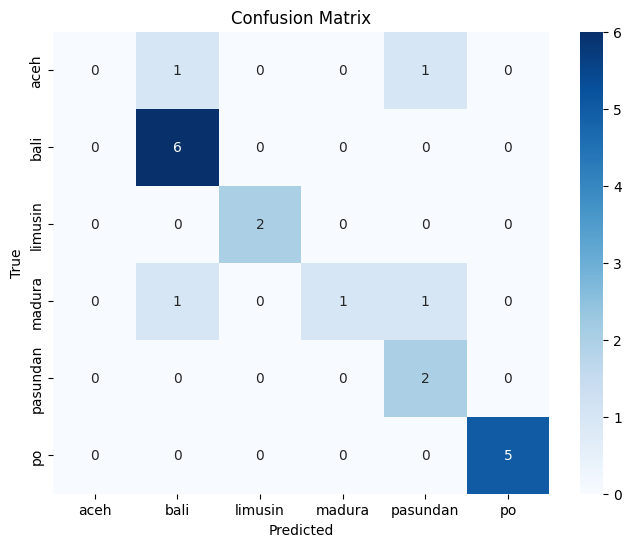


Classification Report:
              precision    recall  f1-score   support

        aceh       0.00      0.00      0.00         2
        bali       0.75      1.00      0.86         6
     limusin       1.00      1.00      1.00         2
      madura       1.00      0.33      0.50         3
    pasundan       0.50      1.00      0.67         2
          po       1.00      1.00      1.00         5

    accuracy                           0.80        20
   macro avg       0.71      0.72      0.67        20
weighted avg       0.78      0.80      0.75        20



Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# 1. Load model
MODEL_PATH = '/content/lokalbest.keras'
model = load_model(MODEL_PATH)

# 2. Definisikan direktori validasi/test
VALID_DIR = '/content/sapi-1/test'  # <-- sesuaikan

# 3. BUAT ulang generator (WAJIB, walau sudah training sebelumnya)
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_generator_cm = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 4. Ambil label asli
y_true = valid_generator_cm.classes
nama_kelas = list(valid_generator_cm.class_indices.keys())

# 5. Prediksi
# Tambahkan ini di poin 5 kode Anda
print("⏳ Predicting...")
y_pred_probs = model.predict(valid_generator_cm)

# Lihat 5 prediksi pertama
print("Contoh Probabilitas :")
print(y_pred_probs[:5])

y_pred = np.argmax(y_pred_probs, axis=1)

#y_pred_probs = model.predict(valid_generator_cm)
#y_pred = np.argmax(y_pred_probs, axis=1)

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=nama_kelas))

Found 119 images belonging to 4 classes.
⏳ Predicting...


4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Contoh Probabilitas (FMD, LSD, Healthy):
[[1.0000000e+00 1.0864738e-11 5.2127305e-08 7.0872398e-11]
 [9.9999881e-01 2.2104544e-08 6.3851672e-08 1.0789191e-06]
 [9.9994898e-01 4.2470190e-05 4.6866635e-06 3.9122110e-06]
 [9.9999642e-01 1.8907414e-07 2.5450668e-11 3.4358141e-06]
 [1.0000000e+00 3.6524192e-10 2.5777114e-10 2.8295103e-08]]


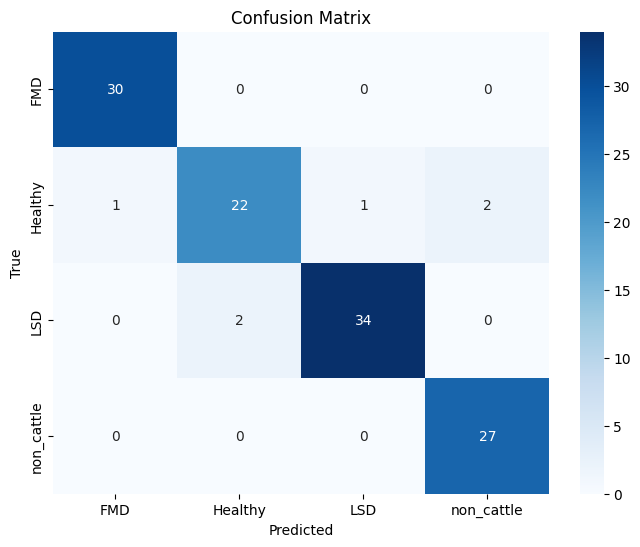


Classification Report:
              precision    recall  f1-score   support

         FMD       0.97      1.00      0.98        30
     Healthy       0.92      0.85      0.88        26
         LSD       0.97      0.94      0.96        36
  non_cattle       0.93      1.00      0.96        27

    accuracy                           0.95       119
   macro avg       0.95      0.95      0.95       119
weighted avg       0.95      0.95      0.95       119



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# 1. Load model
MODEL_PATH = '/content/tes1_last_v3.keras'
model = load_model(MODEL_PATH)

# 2. Definisikan direktori validasi/test
VALID_DIR = '/content/FMD-and-LSD-cattle-disease-3/valid'  # <-- sesuaikan

# 3. BUAT ulang generator (WAJIB, walau sudah training sebelumnya)
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_generator_cm = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 4. Ambil label asli
y_true = valid_generator_cm.classes
nama_kelas = list(valid_generator_cm.class_indices.keys())

# 5. Prediksi
# Tambahkan ini di poin 5 kode Anda
print("⏳ Predicting...")
y_pred_probs = model.predict(valid_generator_cm)

# Lihat 5 prediksi pertama
print("Contoh Probabilitas (FMD, LSD, Healthy):")
print(y_pred_probs[:5])

y_pred = np.argmax(y_pred_probs, axis=1)

#y_pred_probs = model.predict(valid_generator_cm)
#y_pred = np.argmax(y_pred_probs, axis=1)

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 7. Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=nama_kelas))

In [ ]:
print(model.names)

In [ ]:
print(model.task)

detect


**Reformat/Convert to Tflite**

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("pmkbest.keras")

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Default = float32
tflite_model_fp32 = converter.convert()

with open("pmk_fp32.tflite", "wb") as f:
    f.write(tflite_model_fp32)

print("Sukses membuat model_fp32.tflite")

Saved artifact at '/tmp/tmp6hee713h'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134628569627728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569618320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569617552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569618512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569627920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569627536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569622352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569622160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569623696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569628112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628571053904

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimasi
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Float16 quantization
converter.target_spec.supported_types = [tf.float16]

tflite_model_fp16 = converter.convert()

with open("pmk_fp16.tflite", "wb") as f:
    f.write(tflite_model_fp16)

print("Sukses membuat model_fp16.tflite")

Saved artifact at '/tmp/tmpku295_xf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134628569627728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569618320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569617552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569618512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569627920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569627536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569622352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569622160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569623696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628569628112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134628571053904

Cek Input/Output Shape Model

In [ ]:
# Install TFLite tools (jika belum)
!pip install tensorflow

In [ ]:
# Cek model info
import tensorflow as tf;
interpreter = tf.lite.Interpreter(model_path='/content/model.tflite');
interpreter.allocate_tensors();
print('Input:', interpreter.get_input_details());
print('Output:', interpreter.get_output_details())

Input: [{'name': 'images', 'index': 0, 'shape': array([  1, 640, 640,   3], dtype=int32), 'shape_signature': array([  1, 640, 640,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'Identity', 'index': 611, 'shape': array([   1,    8, 8400], dtype=int32), 'shape_signature': array([   1,    8, 8400], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
!pip install roboflow tensorflow

from roboflow import Roboflow

# Masukkan API Key Roboflow
rf = Roboflow(api_key="oSqbdWgbnJkiVfOWl18o")
project = rf.workspace("valll-rtclj").project("fmd-and-lsd-cattle-disease")
version = project.version(3)
dataset = version.download("folder")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FMD-and-LSD-cattle-disease-3 in folder:: 100%|██████████| 1898/1898 [00:00<00:00, 7702.43it/s]


Found 118 images belonging to 4 classes.
Urutan kelas: {'FMD': 0, 'Healthy': 1, 'LSD': 2, 'non_cattle': 3}
Jumlah citra data uji: 118
⏳ Predicting on TEST set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step


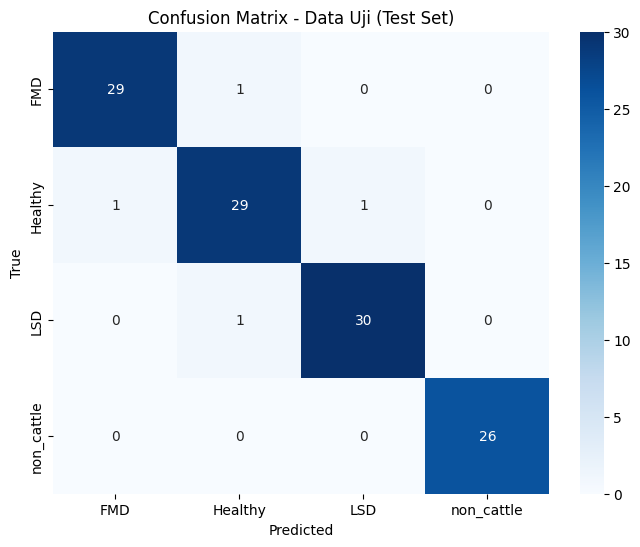


Classification Report (Data Uji):
              precision    recall  f1-score   support

         FMD     0.9667    0.9667    0.9667        30
     Healthy     0.9355    0.9355    0.9355        31
         LSD     0.9677    0.9677    0.9677        31
  non_cattle     1.0000    1.0000    1.0000        26

    accuracy                         0.9661       118
   macro avg     0.9675    0.9675    0.9675       118
weighted avg     0.9661    0.9661    0.9661       118


Accuracy pada data uji: 0.9661 (114 dari 118 citra benar)


    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    



Accuracy TensorFlow Lite pada data uji: 0.9661
Kesepakatan kelas prediksi Keras vs TFLite: 100.00%

Ukuran model TFLite: 11.8077 MB
Checksum SHA-256: ed9598c56b5dc5a5788c0d8376e8d6d2b80277aeca1931183f78cc968eae4bf9


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib, os
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# 1. Load model terbaik (checkpoint val_accuracy tertinggi)
MODEL_PATH = '/content/tes1_best_v3.keras'
model = load_model(MODEL_PATH)

# 2. Arahkan ke folder TEST (bukan valid)
TEST_DIR = f"{dataset.location}/test"   # <-- pakai variabel dataset dari sel training di atas

# 3. Buat generator untuk data uji (shuffle=False wajib, agar y_true sinkron dengan y_pred)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 4. Ambil label asli & nama kelas
y_true = test_generator.classes
nama_kelas = list(test_generator.class_indices.keys())
print("Urutan kelas:", test_generator.class_indices)
print("Jumlah citra data uji:", test_generator.samples)

# 5. Prediksi
print("⏳ Predicting on TEST set...")
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 6. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix - Data Uji (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 7. Classification Report (precision, recall, f1-score, macro avg -> untuk Tabel 4.3)
print("\nClassification Report (Data Uji):")
report_dict = classification_report(y_true, y_pred, target_names=nama_kelas, digits=4)
print(report_dict)

# 8. Ringkasan accuracy + jumlah benar/salah (untuk narasi BAB IV 4.3)
n_correct = int((y_true == y_pred).sum())
n_total = len(y_true)
accuracy = n_correct / n_total
print(f"\nAccuracy pada data uji: {accuracy:.4f} ({n_correct} dari {n_total} citra benar)")

# ==========================================================================
# 9. (Opsional tapi disarankan) Pengujian parity Keras vs TensorFlow Lite
#    pada data uji yang SAMA -> untuk Tabel 4.5 (BAB IV 4.4)
# ==========================================================================
import tensorflow as tf

TFLITE_PATH = '/content/newmodel_fp32.tflite'   # sesuaikan dengan nama file hasil konversi Anda
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# reset generator agar urutan citra sama dari awal
test_generator.reset()

tflite_preds = []
keras_preds = list(y_pred)  # sudah dihitung di atas

idx = 0
for batch_images, _ in test_generator:
    for img in batch_images:
        img_input = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])
        tflite_preds.append(int(np.argmax(out[0])))
        idx += 1
    if idx >= test_generator.samples:
        break

tflite_preds = np.array(tflite_preds[:test_generator.samples])
keras_preds = np.array(keras_preds[:len(tflite_preds)])

agreement = (tflite_preds == keras_preds).mean()
tflite_accuracy = (tflite_preds == y_true[:len(tflite_preds)]).mean()

print(f"\nAccuracy TensorFlow Lite pada data uji: {tflite_accuracy:.4f}")
print(f"Kesepakatan kelas prediksi Keras vs TFLite: {agreement*100:.2f}%")

# 10. Ukuran file & checksum SHA-256 model TFLite (untuk Tabel 3.7 / narasi BAB IV 4.4)
size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
sha256 = hashlib.sha256(open(TFLITE_PATH, 'rb').read()).hexdigest()
print(f"\nUkuran model TFLite: {size_mb:.4f} MB")
print(f"Checksum SHA-256: {sha256}")

In [ ]:
!ls "{dataset.location}/train/FMD" | wc -l

420


In [ ]:
!ls "{dataset.location}/train/LSD" | wc -l

474


In [ ]:
!ls "{dataset.location}/train/Healthy" | wc -l

396


In [ ]:
!ls "{dataset.location}/train/non_cattle" | wc -l

369


In [ ]:
import numpy as np

# Pastikan test_generator sudah di-reset agar urutan citra sama
test_generator.reset()

keras_scores = []   # skor softmax lengkap dari model Keras
tflite_scores = []  # skor softmax lengkap dari model TFLite

idx = 0
for batch_images, _ in test_generator:
    for img in batch_images:
        img_input = np.expand_dims(img, axis=0).astype(np.float32)

        # skor dari model Keras
        keras_out = model.predict(img_input, verbose=0)[0]
        keras_scores.append(keras_out)

        # skor dari model TFLite
        interpreter.set_tensor(input_details[0]['index'], img_input)
        interpreter.invoke()
        tflite_out = interpreter.get_tensor(output_details[0]['index'])[0]
        tflite_scores.append(tflite_out)

        idx += 1
    if idx >= test_generator.samples:
        break

keras_scores = np.array(keras_scores)
tflite_scores = np.array(tflite_scores)

abs_diff = np.abs(keras_scores - tflite_scores)
print(f"Selisih absolut skor keluaran terbesar: {abs_diff.max():.7f}")
print(f"Rata-rata selisih absolut skor keluaran: {abs_diff.mean():.8f}")

# Pastikan selisih tidak mengubah kelas prediksi
keras_argmax = keras_scores.argmax(axis=1)
tflite_argmax = tflite_scores.argmax(axis=1)
print(f"Jumlah citra dengan kelas berbeda akibat selisih skor: {(keras_argmax != tflite_argmax).sum()}")

Selisih absolut skor keluaran terbesar: 0.0000026
Rata-rata selisih absolut skor keluaran: 0.00000006
Jumlah citra dengan kelas berbeda akibat selisih skor: 0
